# Bert Model

In [62]:
from transformers import BertForQuestionAnswering, BertTokenizer
import torch
from rich.pretty import pprint

In [63]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

In [64]:
model = BertForQuestionAnswering.from_pretrained(model_name)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5748.93it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
tokenizer = BertTokenizer.from_pretrained(model_name)

In [66]:
question = "What is Richmond working on at the moment?"
answer_doc = """  
Richmond is a Computer Science student at Caldwell University. 
He is working on an AI Resume Builder project that uses Claude API 
to tailor resumes to job descriptions.
"""

### Embeddings

In [67]:
encoding = tokenizer.encode(text=question, text_pair=answer_doc)

In [68]:
pprint(encoding)

[
│   101,
│   2054,
│   2003,
│   6713,
│   2551,
│   2006,
│   2012,
│   1996,
│   2617,
│   1029,
│   102,
│   6713,
│   2003,
│   1037,
│   3274,
│   2671,
│   3076,
│   2012,
│   16589,
│   2118,
│   1012,
│   2002,
│   2003,
│   2551,
│   2006,
│   2019,
│   9932,
│   13746,
│   12508,
│   2622,
│   2008,
│   3594,
│   8149,
│   17928,
│   2000,
│   22701,
│   13746,
│   2015,
│   2000,
│   3105,
│   13271,
│   1012,
│   102
]

In [69]:
inputs = encoding
# sentence_embedding = 
tokens = tokenizer.convert_ids_to_tokens(inputs)

In [70]:
pprint(tokens)

[
│   '[CLS]',
│   'what',
│   'is',
│   'richmond',
│   'working',
│   'on',
│   'at',
│   'the',
│   'moment',
│   '?',
│   '[SEP]',
│   'richmond',
│   'is',
│   'a',
│   'computer',
│   'science',
│   'student',
│   'at',
│   'caldwell',
│   'university',
│   '.',
│   'he',
│   'is',
│   'working',
│   'on',
│   'an',
│   'ai',
│   'resume',
│   'builder',
│   'project',
│   'that',
│   'uses',
│   'claude',
│   'api',
│   'to',
│   'tailor',
│   'resume',
│   '##s',
│   'to',
│   'job',
│   'descriptions',
│   '.',
│   '[SEP]'
]

In [71]:
output = model(input_ids = torch.tensor([inputs]))

### Model output

In [72]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

pprint(start_index)
pprint(end_index)

tensor(25)

tensor(29)

In [73]:
answer = " ".join(tokens[start_index: end_index + 1])
pprint(answer)

'an ai resume builder project'

### Visiualising the different tokens and the probability of being selected as the start or end tokens

In [74]:
import matplotlib as plt
import seaborn as sns

In [75]:
start_scores = output.start_logits.detach().numpy().flatten()
end_scores = output.end_logits.detach().numpy().flatten()

In [76]:
token_labels = []
for (i, token) in enumerate(tokens):
    pprint(f"Index: {i}, Token: {token}")
    token_labels.append('{:} - {:>2}'.format(token, i))

'Index: 0, Token: [CLS]'

'Index: 1, Token: what'

'Index: 2, Token: is'

'Index: 3, Token: richmond'

'Index: 4, Token: working'

...

'Index: 38, Token: to'

'Index: 39, Token: job'

'Index: 40, Token: descriptions'

'Index: 41, Token: .'

'Index: 42, Token: [SEP]'

In [77]:
pprint(token_labels)

[
│   '[CLS] -  0',
│   'what -  1',
│   'is -  2',
│   'richmond -  3',
│   'working -  4',
│   'on -  5',
│   'at -  6',
│   'the -  7',
│   'moment -  8',
│   '? -  9',
│   '[SEP] - 10',
│   'richmond - 11',
│   'is - 12',
│   'a - 13',
│   'computer - 14',
│   'science - 15',
│   'student - 16',
│   'at - 17',
│   'caldwell - 18',
│   'university - 19',
│   '. - 20',
│   'he - 21',
│   'is - 22',
│   'working - 23',
│   'on - 24',
│   'an - 25',
│   'ai - 26',
│   'resume - 27',
│   'builder - 28',
│   'project - 29',
│   'that - 30',
│   'uses - 31',
│   'claude - 32',
│   'api - 33',
│   'to - 34',
│   'tailor - 35',
│   'resume - 36',
│   '##s - 37',
│   'to - 38',
│   'job - 39',
│   'descriptions - 40',
│   '. - 41',
│   '[SEP] - 42'
]

C:\Users\richm\AppData\Local\Temp\ipykernel_2676\1488797725.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


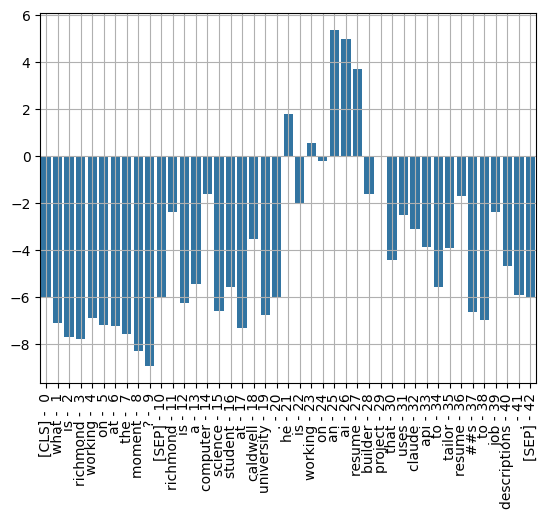

In [78]:
ax = sns.barplot(x=token_labels, y=start_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

C:\Users\richm\AppData\Local\Temp\ipykernel_2676\1375547986.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


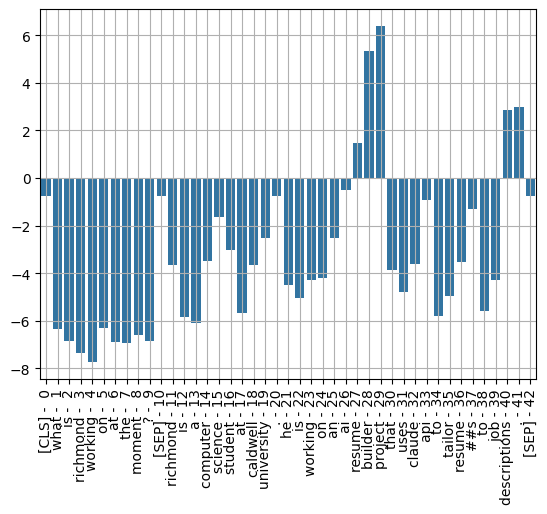

In [79]:
ax = sns.barplot(x=token_labels, y=end_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

### Question and Answering Bot

In [80]:
context = """ 
Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar panels to power the facility, energy-efficient lighting, and a comprehensive recycling program. This commitment to eco-consciousness has earned Sunset Motors recognition as an industry leader in sustainable automotive retail. Sunset Motors proudly offers a diverse range of vehicles, including popular brands like Ford, Toyota, Honda, Chevrolet, and BMW, catering to a wide spectrum of tastes and preferences. In addition to its outstanding vehicle selection, Sunset Motors offers flexible financing options, allowing customers to secure affordable loans and leases with competitive interest rates.
"""

In [81]:
def q_and_a_bot(question):
    input_ids = tokenizer.encode(text=question, text_pair=context)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    # segement embeeddings or capture the token_type_ids
    sep_ids = input_ids.index(tokenizer.sep_token_id)
    # pprint(f"sep_idx: {sep_ids}")
    num_seg_a = sep_ids + 1
    # pprint(f"num_seg_a : {num_seg_a}")
    num_seg_b = len(input_ids) - num_seg_a
    # pprint(f"num_seg_b : {num_seg_b}")
    segment_ids = [0] * num_seg_a + [1]*num_seg_b
    # pprint(f"segment_idx : {segment_idx}")
    # segment ends

    output = model(torch.tensor([input_ids]), token_type_ids = torch.tensor([segment_ids]))
    start_index = torch.argmax(output.start_logits)
    end_index = torch.argmax(output.end_logits)

    if end_index >= start_index:
        answer = " ".join(tokens[start_index : end_index + 1])
    else:
        answer = "Couldn't find answer"
    corrected_answer = ""
    for word in answer.split():
        if word[0:2] == "##":
            corrected_answer +=word[2:]
        else:
            corrected_answer += ' ' + word
    return corrected_answer

In [82]:
print(q_and_a_bot("What is the name of the company?"))

 sunset motors


In [83]:
print(q_and_a_bot("Where is the dealership located?"))

 crestwood


In [84]:
print(q_and_a_bot("what make of cars are available?"))

 ford , toyota , honda , chevrolet , and bmw


In [85]:
print(q_and_a_bot("What is my name?"))

 sunset motors


In [86]:
print(q_and_a_bot("Good morning?"))

 Couldn't find answer


### RoBERTa and DistilBERT

In [87]:

from transformers import RobertaTokenizer, RobertaModel
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1234.24it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [88]:
from transformers import  DistilBertTokenizer, DistilBertModel 
model_name = "distilbert-base-uncased"
tokenizer =  DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2897.44it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# XLNet Model